# LLM vs Human Grading Analysis

Full pipeline comparing 7 LLM models against human TA grades across 40 students, 3 runs, 6 questions.

**File:** `consolidated_results_rerun_4/grading_results_with_ta.csv`  
**Models:** GPT-5, GPT-4o, Claude Opus, Claude Sonnet, Claude Haiku, Gemini 2.5 Pro, Gemini 2.5 Flash  
**Graders:** TA1, TA2, TA3 (total score out of 133)


In [65]:
# Install additional dependencies (run once)
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "pip"])
pkgs = ["pingouin", "matplotlib", "seaborn", "scipy", "statsmodels"]
for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("All dependencies installed.")


All dependencies installed.


In [66]:
import os, ast, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.stats.anova import AnovaRM
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pingouin as pg
from sklearn.metrics import cohen_kappa_score

warnings.filterwarnings("ignore")

# Plotting style
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 110

# Output directory
os.makedirs("outputs", exist_ok=True)

DATA_PATH = "consolidated_results_rerun_4/grading_results_with_ta.csv"
print("Libraries loaded.")


Libraries loaded.


## Phase 1 — Data Ingestion & Preparation


In [67]:
# Load CSV
df = pd.read_csv(DATA_PATH, encoding="utf-8")
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
df.info()


Shape: (840, 13)
Memory usage: 8168.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             840 non-null    int64  
 1   model                  840 non-null    str    
 2   run                    840 non-null    int64  
 3   total_score            840 non-null    float64
 4   total_points           840 non-null    float64
 5   feedback_by_question   840 non-null    str    
 6   overall_feedback       840 non-null    str    
 7   llm_call_time_taken    840 non-null    float64
 8   total_time_taken       840 non-null    float64
 9   ta1_total_score        840 non-null    float64
 10  ta2_total_score        840 non-null    float64
 11  ta3_total_score        840 non-null    float64
 12  ta_grades_by_question  840 non-null    str    
dtypes: float64(7), int64(2), str(4)
memory usage: 85.4 KB


In [68]:
# Parse JSON/dict columns safely
def safe_parse(val):
    if pd.isna(val) or val == "":
        return {}
    try:
        return json.loads(val)
    except (json.JSONDecodeError, TypeError):
        try:
            return ast.literal_eval(val)
        except Exception:
            return {}

df["feedback_parsed"] = df["feedback_by_question"].apply(safe_parse)
df["ta_grades_parsed"] = df["ta_grades_by_question"].apply(safe_parse)

# Check uniqueness of (student_id, model, run)
dupe_mask = df.duplicated(subset=["student_id", "model", "run"])
print(f"Duplicate rows (student_id, model, run): {dupe_mask.sum()}")
if dupe_mask.sum():
    df = df[~dupe_mask].reset_index(drop=True)
    print("Duplicates dropped.")

print(f"\nModels ({df['model'].nunique()}):", df["model"].unique().tolist())
print(f"Students: {df['student_id'].nunique()} | Runs: {sorted(df['run'].unique())}")


Duplicate rows (student_id, model, run): 0

Models (7): ['gpt-5', 'gpt-4o', 'global.anthropic.claude-opus-4-6-v1', 'global.anthropic.claude-sonnet-4-6', 'gemini-2.5-pro', 'global.anthropic.claude-haiku-4-5-20251001-v1:0', 'gemini-2.5-flash']
Students: 40 | Runs: [np.int64(1), np.int64(2), np.int64(3)]


In [69]:
# Missing value analysis
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
print(missing_df[missing_df["missing_count"] > 0])

# Impute missing text feedback
df["overall_feedback"] = df["overall_feedback"].fillna("")
print("\nAfter imputation — remaining nulls in overall_feedback:", df["overall_feedback"].isna().sum())


Empty DataFrame
Columns: [missing_count, missing_%]
Index: []

After imputation — remaining nulls in overall_feedback: 0


## Phase 2 — Feature Engineering


In [70]:
# Aggregate TA scores (handle nulls from ta2 which has some missing)
ta_cols = ["ta1_total_score", "ta2_total_score", "ta3_total_score"]
df["ta_avg"]  = df[ta_cols].mean(axis=1)          # mean ignoring NaN
df["ta_std"]  = df[ta_cols].std(axis=1)            # inter-TA disagreement

# LLM vs human comparison features
df["llm_bias"]      = df["total_score"] - df["ta_avg"]   # positive = LLM over-grades
df["llm_abs_error"] = df["llm_bias"].abs()
df["norm_score"]    = df["total_score"] / df["total_points"]

# Short model labels for plotting
MODEL_LABELS = {
    "gpt-5": "GPT-5",
    "gpt-4o": "GPT-4o",
    "global.anthropic.claude-opus-4-6-v1": "Claude Opus",
    "global.anthropic.claude-sonnet-4-6": "Claude Sonnet",
    "global.anthropic.claude-haiku-4-5-20251001-v1:0": "Claude Haiku",
    "gemini-2.5-pro": "Gemini 2.5 Pro",
    "gemini-2.5-flash": "Gemini 2.5 Flash",
}
df["model_label"] = df["model"].map(MODEL_LABELS)

print(df[["model_label", "ta_avg", "llm_bias", "llm_abs_error", "norm_score"]].head())
print(f"\nta_avg null rows: {df['ta_avg'].isna().sum()}")


  model_label     ta_avg   llm_bias  llm_abs_error  norm_score
0       GPT-5  79.666667   0.833333       0.833333    0.605263
1       GPT-5  79.666667   6.333333       6.333333    0.646617
2       GPT-5  79.666667  12.833333      12.833333    0.695489
3      GPT-4o  79.666667   7.333333       7.333333    0.654135
4      GPT-4o  79.666667   2.333333       2.333333    0.616541

ta_avg null rows: 0


In [71]:
# Extract per-question LLM scores and TA scores into long-form DataFrames

# --- LLM per-question scores ---
llm_q_rows = []
for _, row in df.iterrows():
    for q_id, qdata in row["feedback_parsed"].items():
        llm_q_rows.append({
            "student_id": row["student_id"],
            "model": row["model"],
            "model_label": row["model_label"],
            "run": row["run"],
            "question": f"Q{q_id}",
            "llm_score": qdata.get("score", np.nan),
            "max_points": qdata.get("max_points", np.nan),
        })
df_llm_q = pd.DataFrame(llm_q_rows)

# --- TA per-question scores ---
ta_q_rows = []
for _, row in df.iterrows():
    for q_id, qdata in row["ta_grades_parsed"].items():
        for ta_num in [1, 2, 3]:
            key = f"score_{ta_num}"
            ta_q_rows.append({
                "student_id": row["student_id"],
                "model": row["model"],
                "run": row["run"],
                "question": f"Q{q_id}",
                "ta": f"TA{ta_num}",
                "ta_score": qdata.get(key, np.nan),
                "full_points": qdata.get("full_points", np.nan),
            })
df_ta_q = pd.DataFrame(ta_q_rows)

# Compute per-question TA average (student-level, model-independent)
df_ta_q_avg = (
    df_ta_q.groupby(["student_id", "question"])["ta_score"]
    .mean()
    .reset_index()
    .rename(columns={"ta_score": "ta_avg_q"})
)

# Merge LLM and TA per-question
df_q = df_llm_q.merge(df_ta_q_avg, on=["student_id", "question"], how="left")
df_q["llm_bias_q"] = df_q["llm_score"] - df_q["ta_avg_q"]

print(f"Per-question rows: {len(df_q)}")
df_q.head()


Per-question rows: 5040


,student_id,model,model_label,run,question,llm_score,max_points,ta_avg_q,llm_bias_q
0,1,gpt-5,GPT-5,1,Q1,2.5,19.0,7.000000,-4.500000
1,1,gpt-5,GPT-5,1,Q2,6.0,16.0,16.000000,-10.000000
2,1,gpt-5,GPT-5,1,Q3,15.0,15.0,15.000000,0.000000
3,1,gpt-5,GPT-5,1,Q4,8.0,16.0,8.000000,0.000000
4,1,gpt-5,GPT-5,1,Q5,9.0,27.0,13.666667,-4.666667


## Phase 3 — Descriptive Statistics


In [72]:
# Overall descriptive statistics
num_cols = ["total_score", "ta1_total_score", "ta2_total_score", "ta3_total_score",
            "ta_avg", "ta_std", "llm_bias", "llm_abs_error", "llm_call_time_taken"]
desc = df[num_cols].describe().T
desc["median"] = df[num_cols].median()
print("=== Global Descriptive Statistics ===")
display(desc[["count", "mean", "median", "std", "min", "25%", "75%", "max"]].round(2))


=== Global Descriptive Statistics ===


,count,mean,median,std,min,25%,75%,max
total_score,840.0,75.51,75.00,21.52,0.00,60.00,93.00,131.00
ta1_total_score,840.0,81.91,82.50,16.41,42.00,74.00,95.25,114.00
ta2_total_score,840.0,55.56,57.00,13.59,22.00,44.00,63.25,81.00
ta3_total_score,840.0,81.38,85.50,19.38,35.00,71.75,94.25,115.00
ta_avg,840.0,72.95,74.83,15.49,35.67,66.33,83.50,101.33
ta_std,840.0,15.85,16.51,5.50,1.73,13.87,19.96,23.69
llm_bias,840.0,2.56,3.67,15.74,-74.33,-8.17,14.00,50.67
llm_abs_error,840.0,12.93,11.33,9.33,0.00,5.83,18.04,74.33
llm_call_time_taken,840.0,52.52,41.56,45.14,5.03,25.60,58.74,386.26


In [73]:
# Per-model summary statistics
model_stats = (
    df.groupby("model_label")
    .agg(
        n=("total_score", "count"),
        mean_score=("total_score", "mean"),
        median_score=("total_score", "median"),
        std_score=("total_score", "std"),
        mean_ta_avg=("ta_avg", "mean"),
        mean_bias=("llm_bias", "mean"),
        mean_abs_error=("llm_abs_error", "mean"),
        median_latency_s=("llm_call_time_taken", "median"),
    )
    .round(2)
    .sort_values("mean_abs_error")
)
print("=== Per-Model Summary (sorted by MAE) ===")
display(model_stats)


=== Per-Model Summary (sorted by MAE) ===


,n,mean_score,median_score,std_score,mean_ta_avg,mean_bias,mean_abs_error,median_latency_s
model_label,,,,,,,,
Claude Sonnet,120,75.30,73.50,19.39,72.95,2.35,11.08,54.22
Claude Opus,120,77.45,75.50,19.20,72.95,4.50,11.32,52.64
Gemini 2.5 Flash,120,79.30,78.75,21.80,72.95,6.35,13.11,25.94
Gemini 2.5 Pro,120,79.71,81.50,21.88,72.95,6.76,13.18,37.62
Claude Haiku,120,68.25,61.50,20.62,72.95,-4.70,13.49,27.01
GPT-5,120,76.34,75.00,21.02,72.95,3.39,13.54,134.18
GPT-4o,120,72.20,73.75,24.47,72.95,-0.75,14.76,8.15


In [74]:
# Per-question mean scores: LLM vs TA average (across all models, all students, all runs)
q_summary = (
    df_q.groupby(["model_label", "question"])
    .agg(
        mean_llm=("llm_score", "mean"),
        mean_ta=("ta_avg_q", "mean"),
        mean_bias=("llm_bias_q", "mean"),
    )
    .round(2)
    .reset_index()
)
print("=== Per-Question Mean Scores (all models) ===")
display(q_summary.pivot_table(index="question", columns="model_label",
                               values="mean_llm", aggfunc="mean").round(2))


=== Per-Question Mean Scores (all models) ===


model_label,Claude Haiku,Claude Opus,Claude Sonnet,GPT-4o,GPT-5,Gemini 2.5 Flash,Gemini 2.5 Pro
question,,,,,,,
Q1,8.93,11.02,10.72,8.87,10.35,12.00,11.68
Q2,7.22,9.38,8.43,7.65,10.42,8.38,9.88
Q3,7.91,7.70,7.81,6.85,8.17,8.72,8.57
Q4,9.52,10.29,10.28,12.32,10.21,11.00,9.61
Q5,12.24,12.59,12.39,11.38,11.07,13.38,14.32
Q6,22.44,26.46,25.67,25.13,26.12,25.82,25.64


## Phase 4 — Visualizations


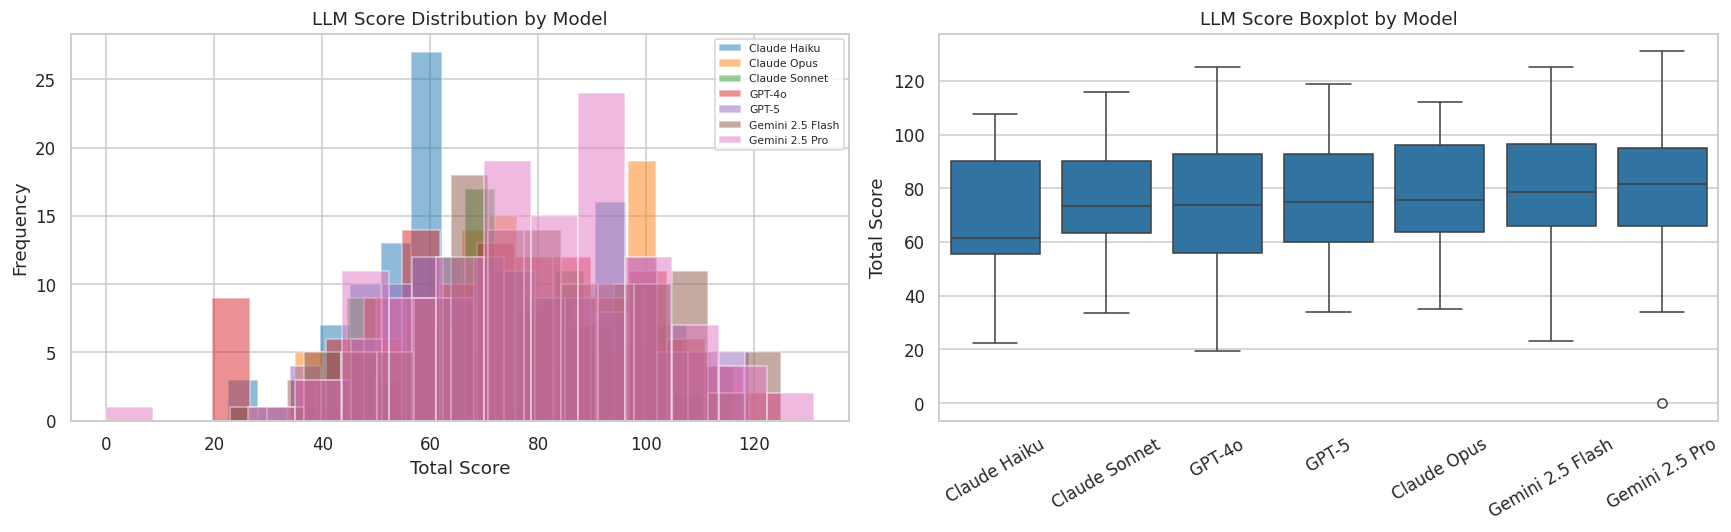

In [75]:
# 4.1 Score distribution: histogram + boxplot per model
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
for label, grp in df.groupby("model_label"):
    axes[0].hist(grp["total_score"], bins=15, alpha=0.5, label=label)
axes[0].set_title("LLM Score Distribution by Model")
axes[0].set_xlabel("Total Score")
axes[0].set_ylabel("Frequency")
axes[0].legend(fontsize=7)

# Boxplot
order = df.groupby("model_label")["total_score"].median().sort_values().index.tolist()
sns.boxplot(data=df, x="model_label", y="total_score", order=order, ax=axes[1])
axes[1].set_title("LLM Score Boxplot by Model")
axes[1].set_xlabel("")
axes[1].set_ylabel("Total Score")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("outputs/4_1_score_distributions.png", bbox_inches="tight")
plt.show()


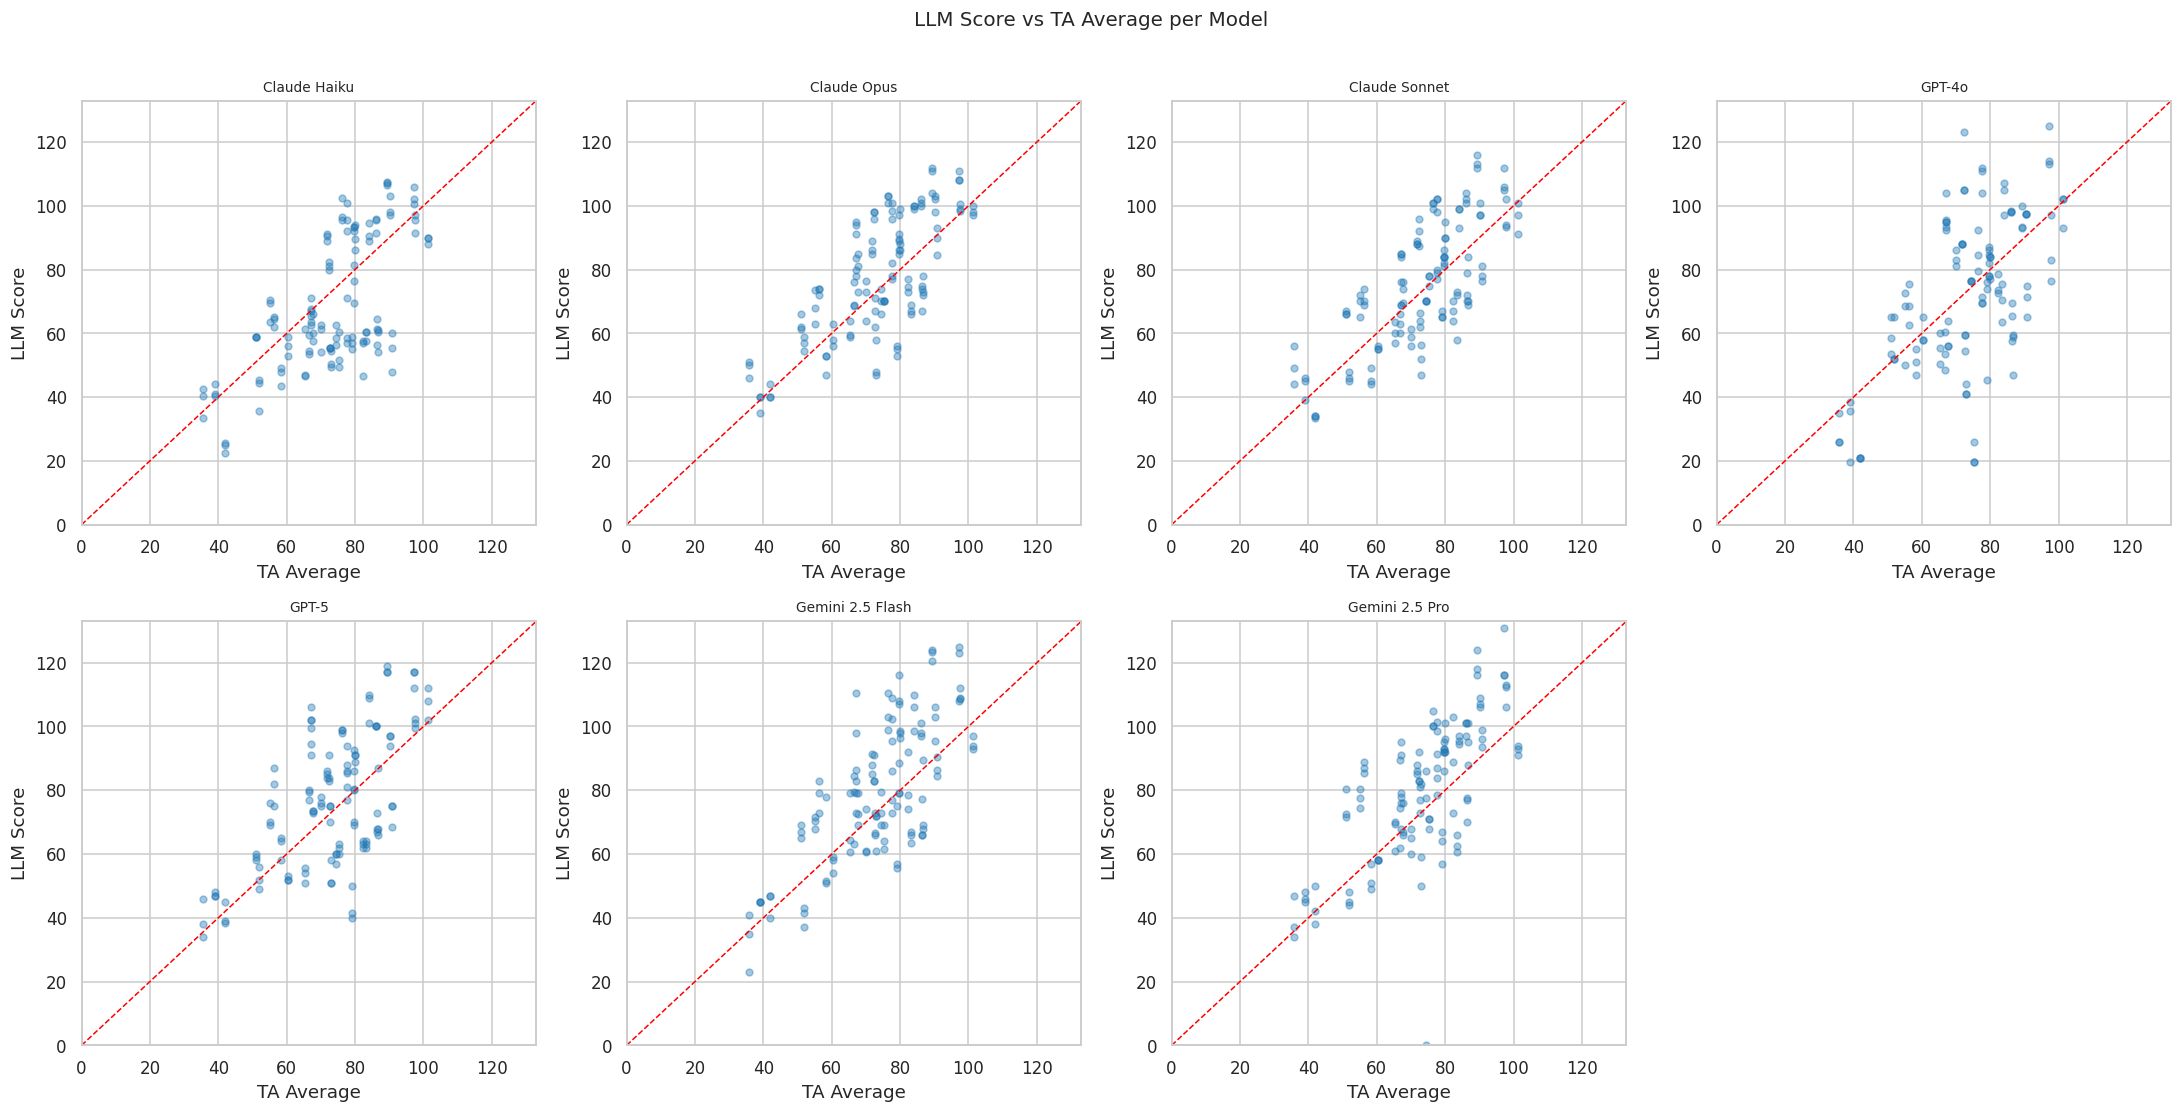

In [76]:
# 4.2 LLM score vs TA average scatter (one panel per model)
models_ordered = sorted(df["model_label"].unique())
n_models = len(models_ordered)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, mlabel in enumerate(models_ordered):
    ax = axes[i]
    sub = df[df["model_label"] == mlabel]
    ax.scatter(sub["ta_avg"], sub["total_score"], alpha=0.4, s=20)
    # Identity line
    lims = [0, 133]
    ax.plot(lims, lims, "r--", linewidth=1, label="y=x")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(mlabel, fontsize=9)
    ax.set_xlabel("TA Average"); ax.set_ylabel("LLM Score")

# Hide unused subplot
for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("LLM Score vs TA Average per Model", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("outputs/4_2_llm_vs_ta_scatter.png", bbox_inches="tight")
plt.show()


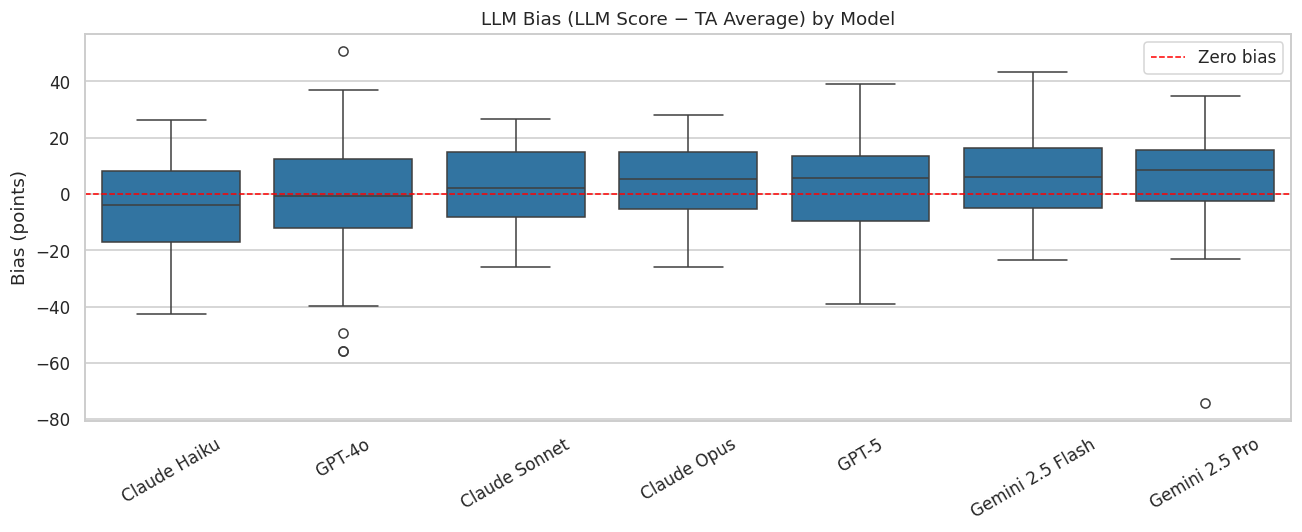

In [77]:
# 4.3 Bias (LLM - TA_avg) boxplot per model
bias_order = df.groupby("model_label")["llm_bias"].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x="model_label", y="llm_bias", order=bias_order, ax=ax)
ax.axhline(0, color="red", linestyle="--", linewidth=1, label="Zero bias")
ax.set_title("LLM Bias (LLM Score − TA Average) by Model")
ax.set_xlabel("")
ax.set_ylabel("Bias (points)")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.savefig("outputs/4_3_bias_boxplot.png", bbox_inches="tight")
plt.show()


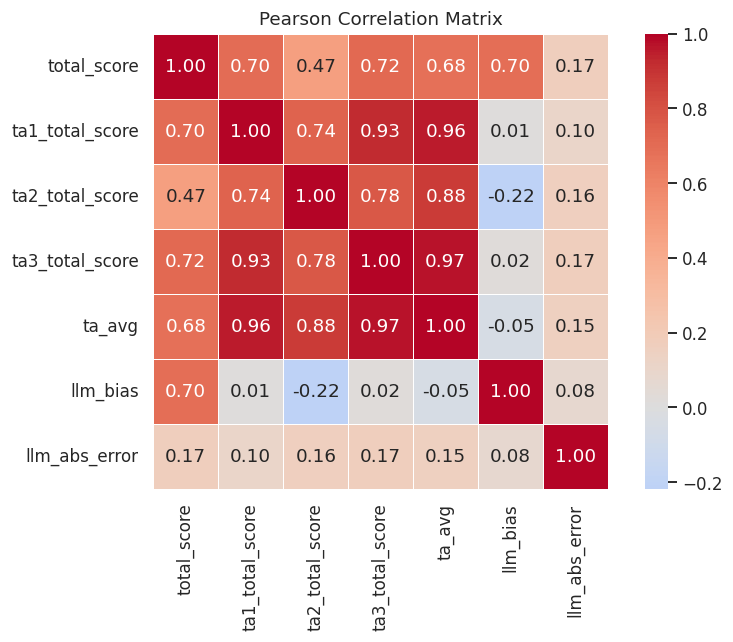

In [78]:
# 4.4 Correlation heatmap
corr_cols = ["total_score", "ta1_total_score", "ta2_total_score", "ta3_total_score",
             "ta_avg", "llm_bias", "llm_abs_error"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Pearson Correlation Matrix")
plt.tight_layout()
plt.savefig("outputs/4_4_correlation_heatmap.png", bbox_inches="tight")
plt.show()


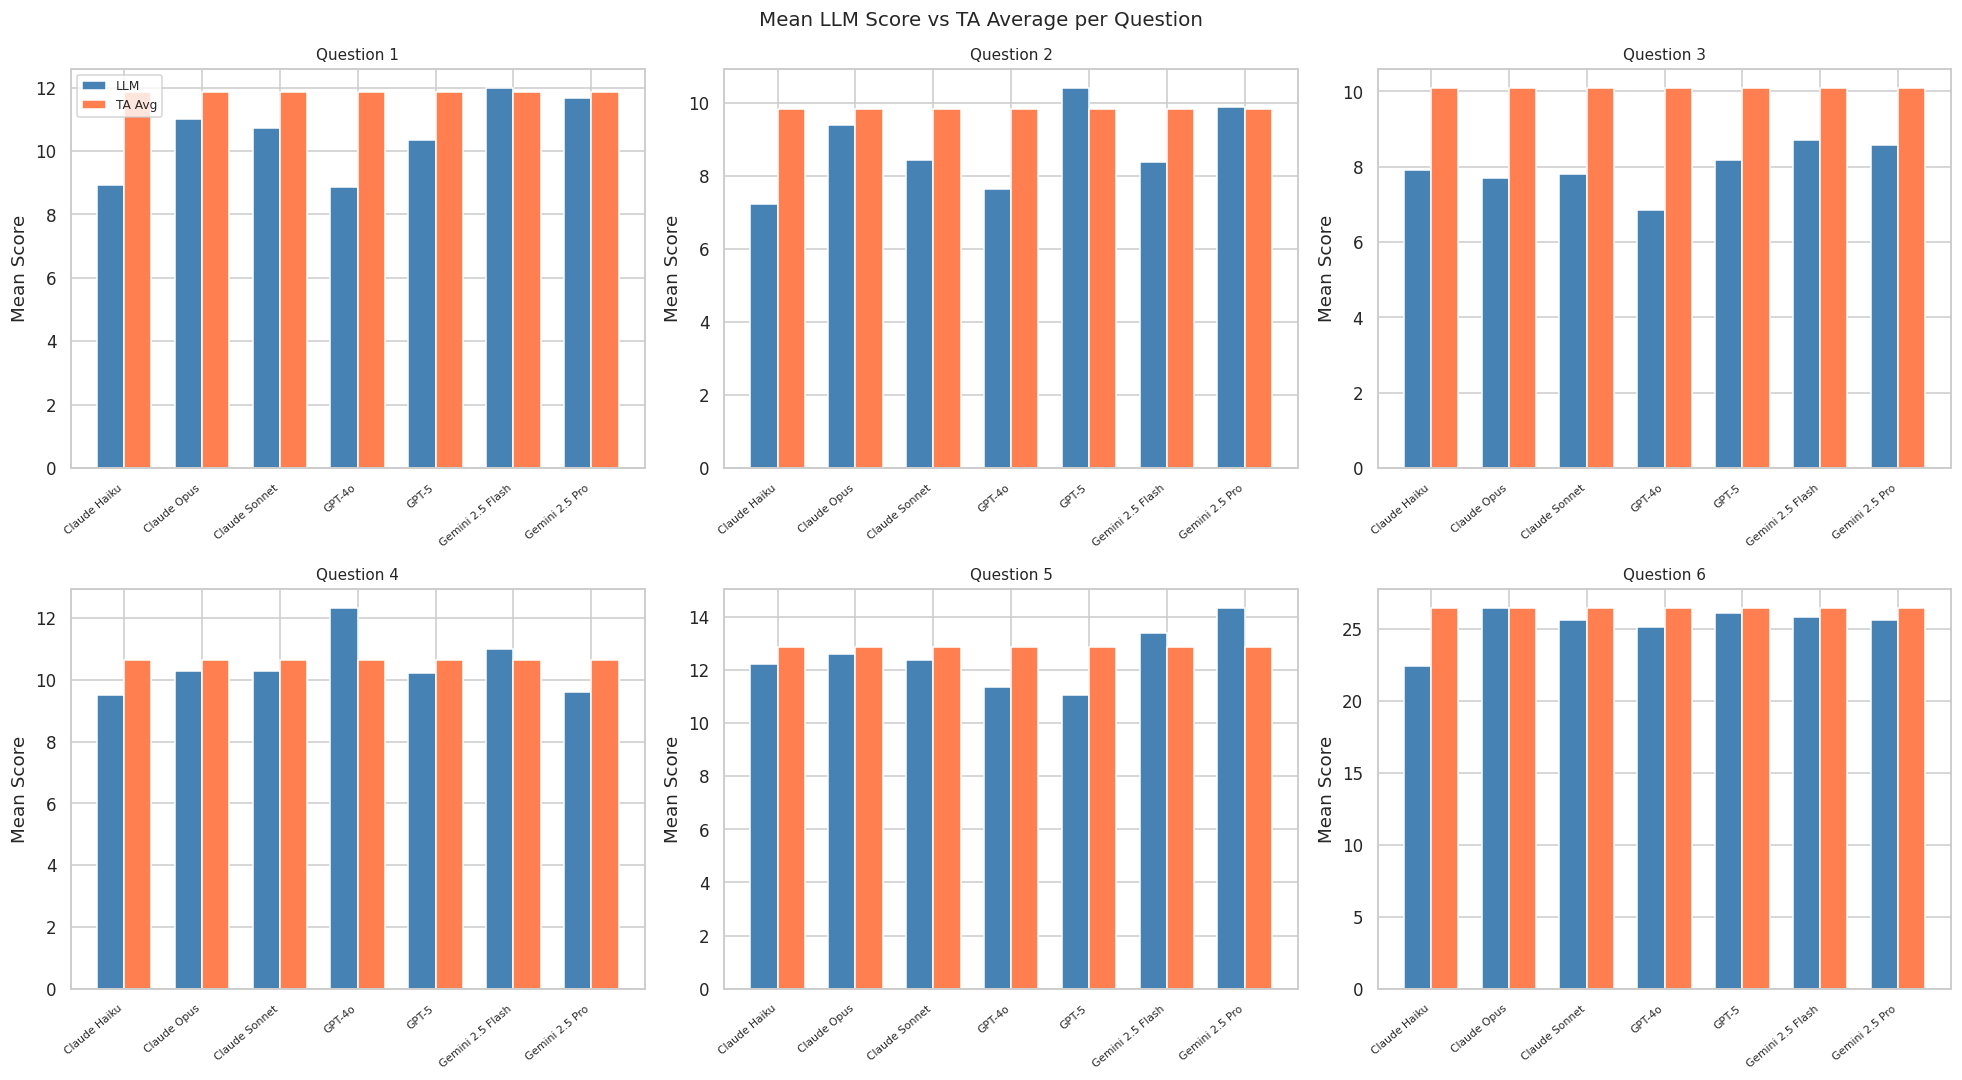

In [79]:
# 4.5 Per-question mean LLM score vs TA score (grouped bar, all models)
questions = sorted(df_q["question"].unique())
q_means = (
    df_q.groupby(["model_label", "question"])[["llm_score", "ta_avg_q"]]
    .mean()
    .reset_index()
)

# One subplot per question
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, q in enumerate(questions):
    ax = axes[idx]
    sub = q_means[q_means["question"] == q].sort_values("model_label")
    x = np.arange(len(sub))
    w = 0.35
    ax.bar(x - w/2, sub["llm_score"], w, label="LLM", color="steelblue")
    ax.bar(x + w/2, sub["ta_avg_q"], w, label="TA Avg", color="coral")
    ax.set_title(f"Question {q[1:]}", fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["model_label"], rotation=40, ha="right", fontsize=7)
    ax.set_ylabel("Mean Score")
    if idx == 0:
        ax.legend(fontsize=8)

fig.suptitle("Mean LLM Score vs TA Average per Question", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/4_5_per_question_bar.png", bbox_inches="tight")
plt.show()


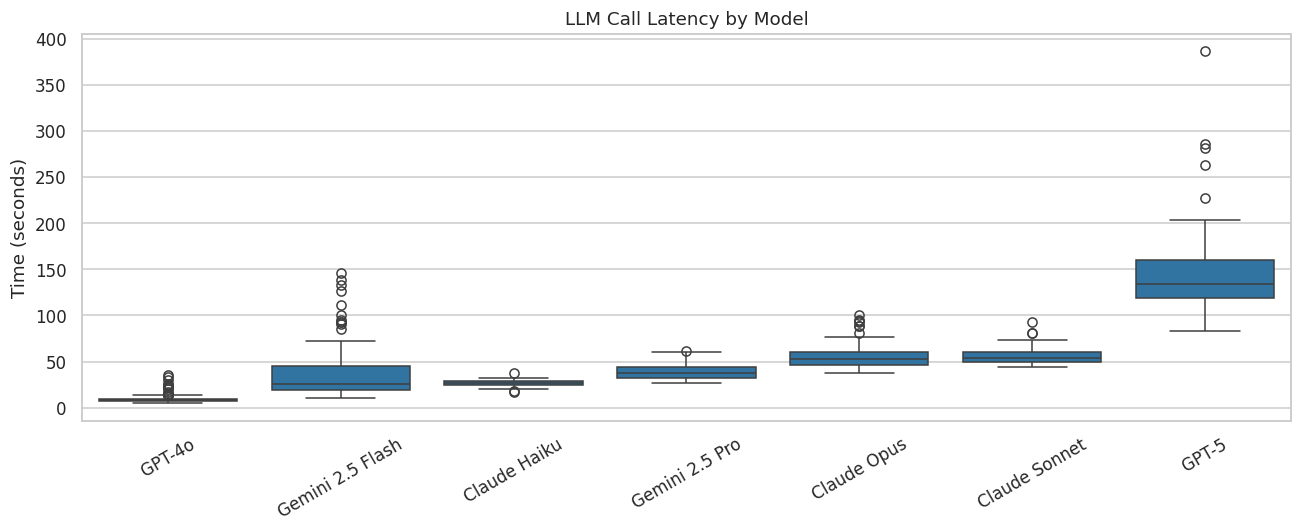

In [80]:
# 4.6 Latency boxplot per model
lat_order = df.groupby("model_label")["llm_call_time_taken"].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x="model_label", y="llm_call_time_taken", order=lat_order, ax=ax)
ax.set_title("LLM Call Latency by Model")
ax.set_xlabel("")
ax.set_ylabel("Time (seconds)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("outputs/4_6_latency_boxplot.png", bbox_inches="tight")
plt.show()


## Phase 5 — Agreement Metrics

For each model we compute: Pearson r, Spearman ρ, MAE, RMSE, mean bias, ICC(2,1), weighted Cohen's κ, and Bland–Altman analysis.


In [81]:
# 5.1 Pearson, Spearman, MAE, RMSE, Bias per model
from scipy.stats import pearsonr, spearmanr

agreement_rows = []
for mlabel, grp in df.groupby("model_label"):
    sub = grp[["total_score", "ta_avg"]].dropna()
    x, y = sub["total_score"].values, sub["ta_avg"].values
    if len(x) < 3:
        continue
    pr, pp = pearsonr(x, y)
    sr, sp = spearmanr(x, y)
    mae  = np.mean(np.abs(x - y))
    rmse = np.sqrt(np.mean((x - y) ** 2))
    bias = np.mean(x - y)
    agreement_rows.append({
        "model": mlabel,
        "n": len(x),
        "pearson_r": round(pr, 3),
        "pearson_p": pp,
        "spearman_rho": round(sr, 3),
        "spearman_p": sp,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "mean_bias": round(bias, 2),
    })

agreement_df = pd.DataFrame(agreement_rows).sort_values("MAE")
print("=== Agreement Metrics per Model ===")

# Format p-values in scientific notation for display
display_df = agreement_df.set_index("model").copy()
display_df["pearson_p"]  = display_df["pearson_p"].map(lambda v: f"{v:.2e}")
display_df["spearman_p"] = display_df["spearman_p"].map(lambda v: f"{v:.2e}")
display(display_df)


=== Agreement Metrics per Model ===


,n,pearson_r,pearson_p,spearman_rho,spearman_p,MAE,RMSE,mean_bias
model,,,,,,,,
Claude Sonnet,120,0.750,6.71e-23,0.718,2.66e-20,11.08,13.03,2.35
Claude Opus,120,0.741,4.02e-22,0.694,1.60e-18,11.32,13.67,4.50
Gemini 2.5 Flash,120,0.734,1.41e-21,0.661,2.09e-16,13.11,16.05,6.35
Gemini 2.5 Pro,120,0.719,2.32e-20,0.725,7.49e-21,13.18,16.58,6.76
Claude Haiku,120,0.671,4.98e-17,0.588,1.61e-12,13.49,16.02,-4.70
GPT-5,120,0.650,8.94e-16,0.578,4.87e-12,13.54,16.37,3.39
GPT-4o,120,0.624,2.77e-14,0.557,4.07e-11,14.76,19.07,-0.75


In [ ]:
# 5.2 Intraclass Correlation (ICC) per model using pingouin
# ICC(2,1): two-way random, single measures, absolute agreement
icc_rows = []
for mlabel, grp in df.groupby("model_label"):
    sub = grp[["student_id", "total_score", "ta1_total_score",
               "ta2_total_score", "ta3_total_score"]].dropna()
    if len(sub) < 5:
        continue
    # Build long format: student x rater
    long = pd.melt(
        sub.rename(columns={"total_score": "LLM",
                             "ta1_total_score": "TA1",
                             "ta2_total_score": "TA2",
                             "ta3_total_score": "TA3"}),
        id_vars="student_id",
        value_vars=["LLM", "TA1", "TA2", "TA3"],
        var_name="rater",
        value_name="score",
    ).dropna()
    try:
        icc = pg.intraclass_corr(data=long, targets="student_id",
                                  raters="rater", ratings="score")
        row = icc[icc["Type"] == "ICC2"].iloc[0]
        icc_rows.append({
            "model": mlabel,
            "ICC(2,1)": round(row["ICC"], 3),
            "CI_lower": round(row["CI95"][0], 3),
            "CI_upper": round(row["CI95"][1], 3),
            "F_p": row["pval"],
        })
    except Exception as e:
        print(f"Error calculating ICC for model {mlabel}: {e}")
        icc_rows.append({"model": mlabel, "ICC(2,1)": np.nan,
                         "CI_lower": np.nan, "CI_upper": np.nan, "F_p": np.nan})

icc_df = pd.DataFrame(icc_rows).sort_values("ICC(2,1)", ascending=False)
print("=== ICC(2,1) per Model (ICC > 0.90 = excellent, 0.75-0.90 = good) ===")

display_icc = icc_df.set_index("model").copy()
display_icc["F_p"] = display_icc["F_p"].map(lambda v: f"{v:.2e}" if pd.notna(v) else np.nan)
display(display_icc)


=== ICC(2,1) per Model (ICC > 0.90 = excellent, 0.75-0.90 = good) ===


,"ICC(2,1)",CI_lower,CI_upper,F_p
model,,,,
Claude Sonnet,0.501,0.16,0.73,3.87e-27
Gemini 2.5 Flash,0.496,0.16,0.72,1.69e-26
Gemini 2.5 Pro,0.496,0.16,0.73,4.06e-27
Claude Opus,0.493,0.16,0.72,8.22e-27
Claude Haiku,0.472,0.16,0.70,2.89e-23
GPT-5,0.468,0.16,0.69,2.78e-22
GPT-4o,0.462,0.18,0.68,7.08e-20


In [83]:
# 5.3 Weighted Cohen's κ per model
# Bin scores into grade categories (out of 133)
def score_to_grade(score, max_score=133):
    pct = score / max_score * 100 if not np.isnan(score) else np.nan
    if np.isnan(pct): return np.nan
    if pct >= 90: return 4   # A
    if pct >= 80: return 3   # B
    if pct >= 70: return 2   # C
    if pct >= 60: return 1   # D
    return 0                  # F

df["llm_grade"]   = df["total_score"].apply(score_to_grade)
df["ta_avg_grade"] = df["ta_avg"].apply(score_to_grade)

kappa_rows = []
for mlabel, grp in df.groupby("model_label"):
    sub = grp[["llm_grade", "ta_avg_grade"]].dropna()
    if len(sub) < 3:
        continue
    try:
        kw = cohen_kappa_score(
            sub["llm_grade"].astype(int),
            sub["ta_avg_grade"].astype(int),
            weights="quadratic",
            labels=[0, 1, 2, 3, 4]
        )
        kappa_rows.append({"model": mlabel, "weighted_kappa": round(kw, 3), "n": len(sub)})
    except Exception as e:
        kappa_rows.append({"model": mlabel, "weighted_kappa": np.nan, "n": len(sub)})

kappa_df = pd.DataFrame(kappa_rows).sort_values("weighted_kappa", ascending=False)
print("=== Weighted Cohen's κ per Model (quadratic, grade bins) ===")
print("κ > 0.8 = strong agreement, 0.6-0.8 = moderate")
display(kappa_df.set_index("model"))


=== Weighted Cohen's κ per Model (quadratic, grade bins) ===
κ > 0.8 = strong agreement, 0.6-0.8 = moderate


,weighted_kappa,n
model,,
Claude Sonnet,0.480,120
Gemini 2.5 Pro,0.475,120
GPT-5,0.458,120
Claude Haiku,0.444,120
Claude Opus,0.443,120
Gemini 2.5 Flash,0.395,120
GPT-4o,0.323,120


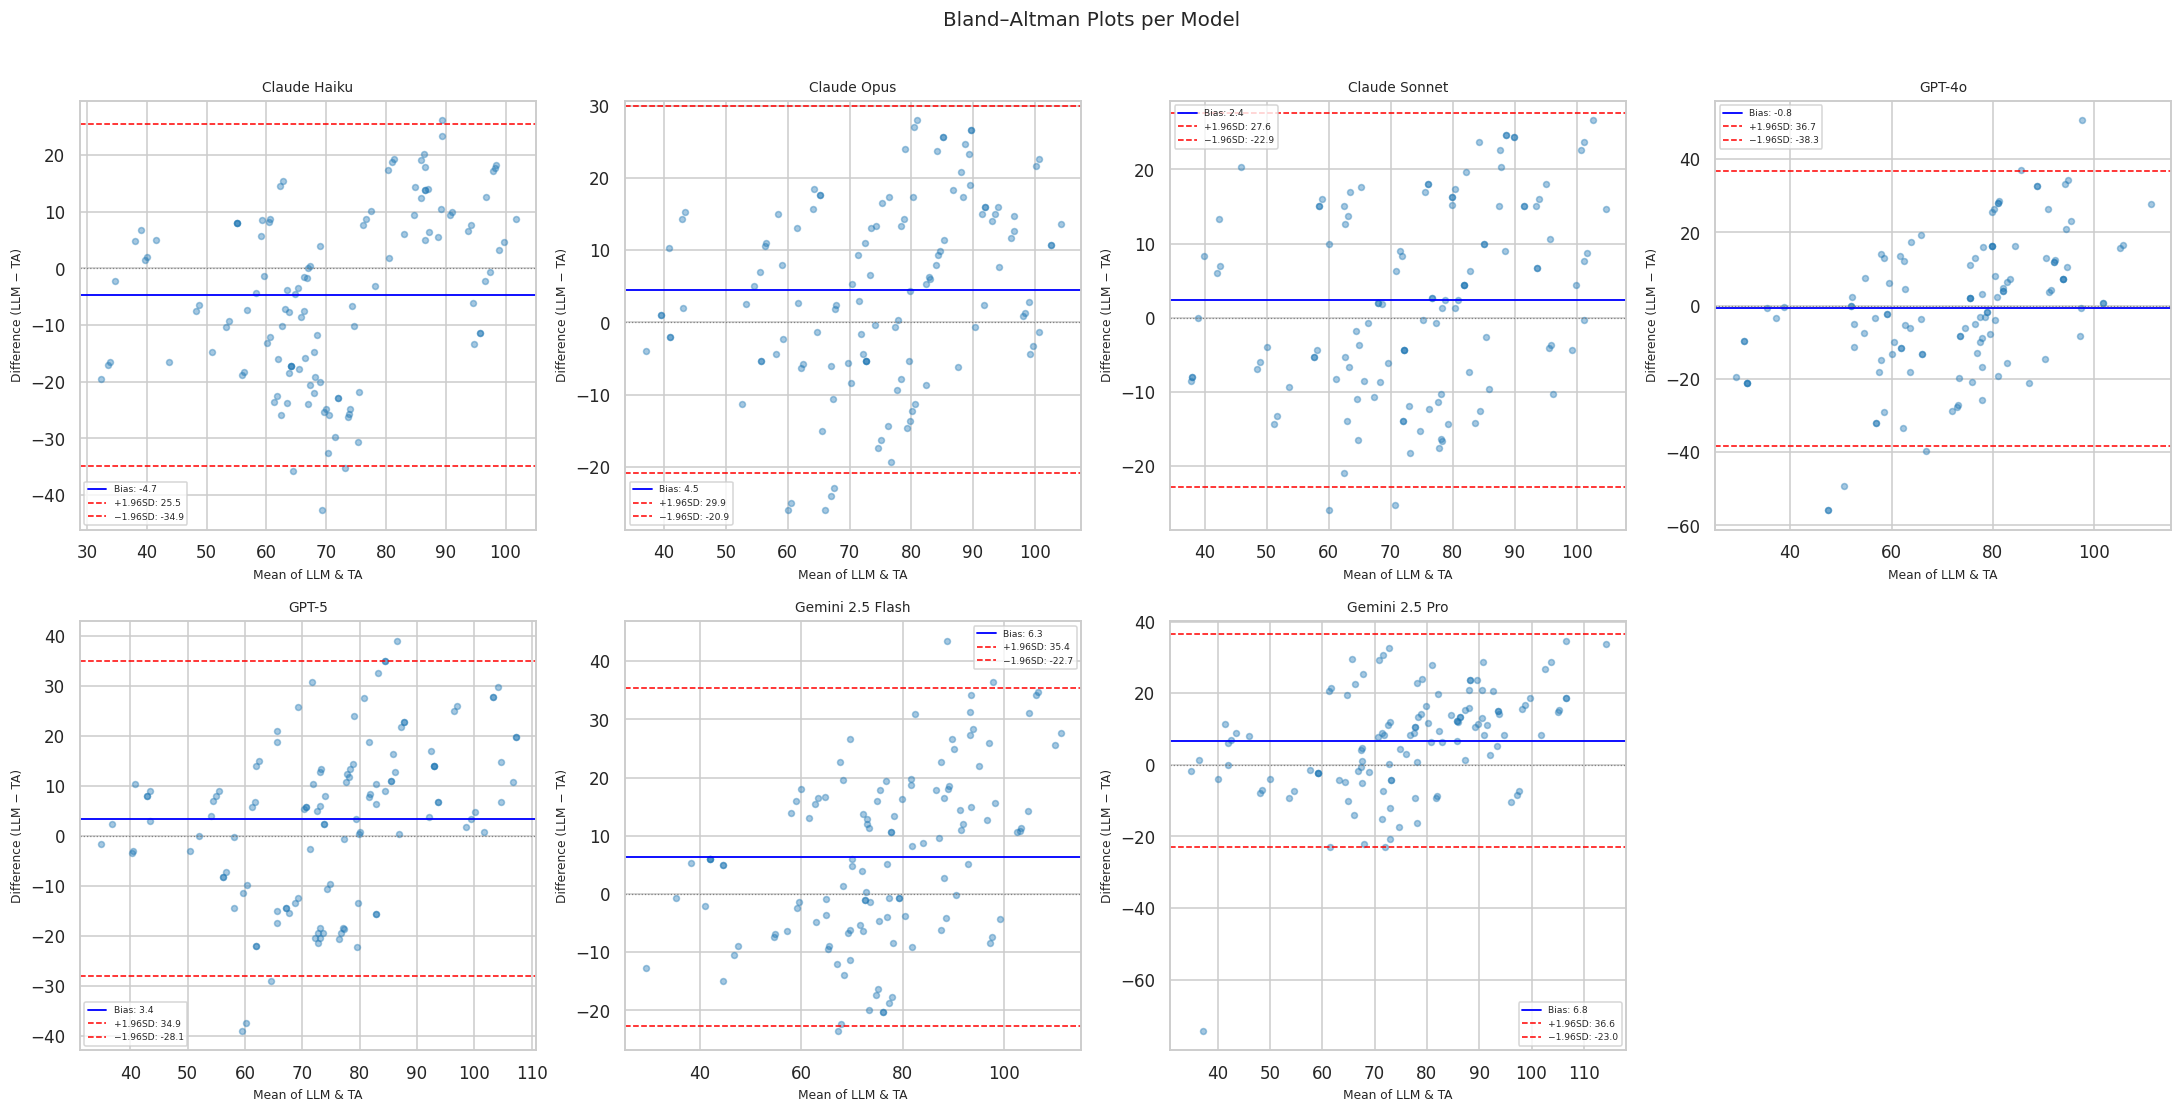

In [84]:
# 5.4 Bland–Altman plots per model
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, mlabel in enumerate(models_ordered):
    ax = axes[i]
    sub = df[df["model_label"] == mlabel][["total_score", "ta_avg"]].dropna()
    mean_vals = (sub["total_score"] + sub["ta_avg"]) / 2
    diff_vals = sub["total_score"] - sub["ta_avg"]

    bias    = diff_vals.mean()
    sd      = diff_vals.std()
    loa_hi  = bias + 1.96 * sd
    loa_lo  = bias - 1.96 * sd

    ax.scatter(mean_vals, diff_vals, alpha=0.4, s=15)
    ax.axhline(bias,   color="blue",  linestyle="-",  linewidth=1.2,
               label=f"Bias: {bias:.1f}")
    ax.axhline(loa_hi, color="red",   linestyle="--", linewidth=1,
               label=f"+1.96SD: {loa_hi:.1f}")
    ax.axhline(loa_lo, color="red",   linestyle="--", linewidth=1,
               label=f"−1.96SD: {loa_lo:.1f}")
    ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
    ax.set_title(mlabel, fontsize=9)
    ax.set_xlabel("Mean of LLM & TA", fontsize=8)
    ax.set_ylabel("Difference (LLM − TA)", fontsize=8)
    ax.legend(fontsize=6)

for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Bland–Altman Plots per Model", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("outputs/5_4_bland_altman.png", bbox_inches="tight")
plt.show()


## Phase 6 — Outlier Detection


In [85]:
# 6.1 IQR rule on total_score and llm_bias
def iqr_outlier_flag(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)

# 6.2 Z-score flag (|z| > 3)
def zscore_flag(series):
    z = np.abs(stats.zscore(series.dropna()))
    flags = pd.Series(False, index=series.index)
    flags[series.dropna().index] = z > 3
    return flags

df["outlier_iqr_score"] = iqr_outlier_flag(df["total_score"])
df["outlier_z_score"]   = zscore_flag(df["total_score"])
df["outlier_iqr_bias"]  = iqr_outlier_flag(df["llm_bias"])
df["outlier_z_bias"]    = zscore_flag(df["llm_bias"])
df["is_outlier"]        = df[["outlier_iqr_score", "outlier_z_score",
                               "outlier_iqr_bias",  "outlier_z_bias"]].any(axis=1)

outliers = df[df["is_outlier"]][["student_id", "model_label", "run",
                                   "total_score", "ta_avg", "llm_bias"]]
print(f"Outlier rows flagged: {len(outliers)}")
display(outliers.sort_values("llm_bias").head(20))


Outlier rows flagged: 6


,student_id,model_label,run,total_score,ta_avg,llm_bias
160,16,Gemini 2.5 Pro,2,0.0,74.333333,-74.333333
66,12,GPT-4o,1,19.5,75.333333,-55.833333
67,12,GPT-4o,2,19.5,75.333333,-55.833333
68,12,GPT-4o,3,26.0,75.333333,-49.333333
415,27,Claude Haiku,2,48.0,90.666667,-42.666667
719,40,GPT-4o,3,123.0,72.333333,50.666667


Outlier count per model:
model_label
GPT-4o              4
Gemini 2.5 Pro      1
Claude Haiku        1
Claude Sonnet       0
Claude Opus         0
GPT-5               0
Gemini 2.5 Flash    0


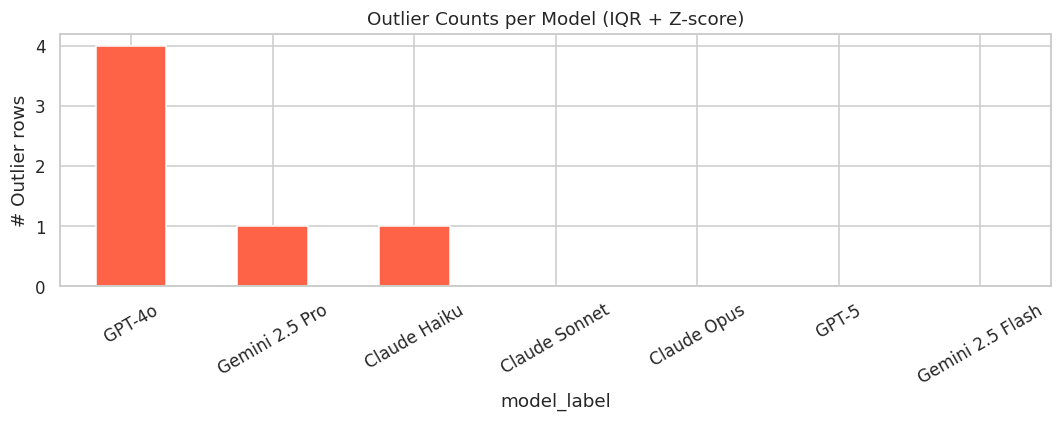

In [86]:
# 6.3 Outlier count per model
outlier_by_model = df.groupby("model_label")["is_outlier"].sum().sort_values(ascending=False)
print("Outlier count per model:")
print(outlier_by_model.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
outlier_by_model.plot(kind="bar", ax=ax, color="tomato")
ax.set_title("Outlier Counts per Model (IQR + Z-score)")
ax.set_ylabel("# Outlier rows")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("outputs/6_3_outlier_counts.png", bbox_inches="tight")
plt.show()


## Phase 7 — Statistical Tests & Model Ranking


In [87]:
# 7.1 Paired t-test & Wilcoxon signed-rank per model (H0: mean bias = 0)
from scipy.stats import ttest_rel, wilcoxon

test_rows = []
for mlabel, grp in df.groupby("model_label"):
    sub = grp[["total_score", "ta_avg"]].dropna()
    x, y = sub["total_score"].values, sub["ta_avg"].values
    if len(x) < 3:
        continue
    t_stat, t_p   = ttest_rel(x, y)
    try:
        w_stat, w_p = wilcoxon(x - y)
    except ValueError:
        w_stat, w_p = np.nan, np.nan

    test_rows.append({
        "model": mlabel,
        "n": len(x),
        "t_stat": round(t_stat, 3),
        "t_p": round(t_p, 4),
        "wilcoxon_stat": round(w_stat, 1) if not np.isnan(w_stat) else np.nan,
        "wilcoxon_p": round(w_p, 4) if not np.isnan(w_p) else np.nan,
        "bias_sig": "YES" if t_p < 0.05 else "no",
    })

tests_df = pd.DataFrame(test_rows).sort_values("t_p")
print("=== Paired Tests: Is LLM bias significantly ≠ 0? ===")
display(tests_df.set_index("model"))


=== Paired Tests: Is LLM bias significantly ≠ 0? ===


,n,t_stat,t_p,wilcoxon_stat,wilcoxon_p,bias_sig
model,,,,,,
Gemini 2.5 Pro,120,4.868,0.0000,1635.5,0.0000,YES
Gemini 2.5 Flash,120,4.698,0.0000,2073.5,0.0000,YES
Claude Opus,120,3.806,0.0002,2242.0,0.0003,YES
Claude Haiku,120,-3.347,0.0011,2453.0,0.0031,YES
GPT-5,120,2.311,0.0226,2728.0,0.0256,YES
Claude Sonnet,120,2.003,0.0474,2851.5,0.0567,YES
GPT-4o,120,-0.432,0.6666,3401.0,0.7687,no


In [88]:
# 7.2 One-way ANOVA: does MAE differ across models?
from scipy.stats import f_oneway

anova_groups = [grp["llm_abs_error"].dropna().values
                for _, grp in df.groupby("model_label")]
f_stat, anova_p = f_oneway(*anova_groups)
print(f"One-way ANOVA on MAE across models: F={f_stat:.3f}, p={anova_p:.4f}")
if anova_p < 0.05:
    print("→ Significant difference in MAE between models (p < 0.05). Running Tukey HSD...")
else:
    print("→ No significant difference between models.")


One-way ANOVA on MAE across models: F=2.349, p=0.0295
→ Significant difference in MAE between models (p < 0.05). Running Tukey HSD...


In [89]:
# 7.3 Tukey HSD post-hoc test (if ANOVA is significant)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df["llm_abs_error"].dropna(),
    groups=df.loc[df["llm_abs_error"].notna(), "model_label"],
    alpha=0.05
)
print(tukey.summary())


          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1           group2      meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------------
    Claude Haiku      Claude Opus  -2.1681 0.5419 -5.7093 1.3732  False
    Claude Haiku    Claude Sonnet  -2.4069 0.4097 -5.9482 1.1343  False
    Claude Haiku           GPT-4o   1.2681 0.9399 -2.2732 4.8093  False
    Claude Haiku            GPT-5     0.05    1.0 -3.4912 3.5912  False
    Claude Haiku Gemini 2.5 Flash  -0.3833 0.9999 -3.9245 3.1579  False
    Claude Haiku   Gemini 2.5 Pro  -0.3139    1.0 -3.8551 3.2273  False
     Claude Opus    Claude Sonnet  -0.2389    1.0 -3.7801 3.3023  False
     Claude Opus           GPT-4o   3.4361 0.0639 -0.1051 6.9773  False
     Claude Opus            GPT-5   2.2181 0.5136 -1.3232 5.7593  False
     Claude Opus Gemini 2.5 Flash   1.7847 0.7511 -1.7565 5.3259  False
     Claude Opus   Gemini 2.5 Pro   1.8542 0.7158  -1.687 5.3954

In [90]:
# 7.4 Final Model Ranking Table
# Combine all metrics: lower MAE/RMSE/|bias| is better; higher pearson_r/ICC/kappa is better

ranking = (
    agreement_df[["model", "pearson_r", "MAE", "RMSE", "mean_bias"]]
    .merge(icc_df[["model", "ICC(2,1)"]], on="model", how="left")
    .merge(kappa_df[["model", "weighted_kappa"]], on="model", how="left")
    .merge(
        df.groupby("model_label")["llm_call_time_taken"].median()
          .reset_index().rename(columns={"model_label": "model", "llm_call_time_taken": "median_latency_s"}),
        on="model", how="left"
    )
)

# Composite rank: rank each metric and sum (lower rank = better)
ranking["rank_MAE"]    = ranking["MAE"].rank()
ranking["rank_r"]      = ranking["pearson_r"].rank(ascending=False)
ranking["rank_ICC"]    = ranking["ICC(2,1)"].rank(ascending=False)
ranking["rank_kappa"]  = ranking["weighted_kappa"].rank(ascending=False)
ranking["rank_bias"]   = ranking["mean_bias"].abs().rank()
ranking["rank_latency"]= ranking["median_latency_s"].rank()
ranking["composite_rank"] = (
    ranking[["rank_MAE", "rank_r", "rank_ICC", "rank_kappa", "rank_bias"]].mean(axis=1)
)
ranking = ranking.sort_values("composite_rank")

print("=== Final Model Ranking (lower composite rank = better alignment with TAs) ===")
display(ranking.set_index("model")[[
    "pearson_r", "MAE", "RMSE", "mean_bias", "ICC(2,1)",
    "weighted_kappa", "median_latency_s", "composite_rank"
]].round(3))


=== Final Model Ranking (lower composite rank = better alignment with TAs) ===


,pearson_r,MAE,RMSE,mean_bias,"ICC(2,1)",weighted_kappa,median_latency_s,composite_rank
model,,,,,,,,
Claude Sonnet,0.750,11.08,13.03,2.35,0.501,0.480,54.220,1.2
Claude Opus,0.741,11.32,13.67,4.50,0.493,0.443,52.638,3.4
Gemini 2.5 Pro,0.719,13.18,16.58,6.76,0.496,0.475,37.621,3.9
Gemini 2.5 Flash,0.734,13.11,16.05,6.35,0.496,0.395,25.936,4.1
Claude Haiku,0.671,13.49,16.02,-4.70,0.472,0.444,27.015,4.8
GPT-5,0.650,13.54,16.37,3.39,0.468,0.458,134.184,4.8
GPT-4o,0.624,14.76,19.07,-0.75,0.462,0.323,8.151,5.8


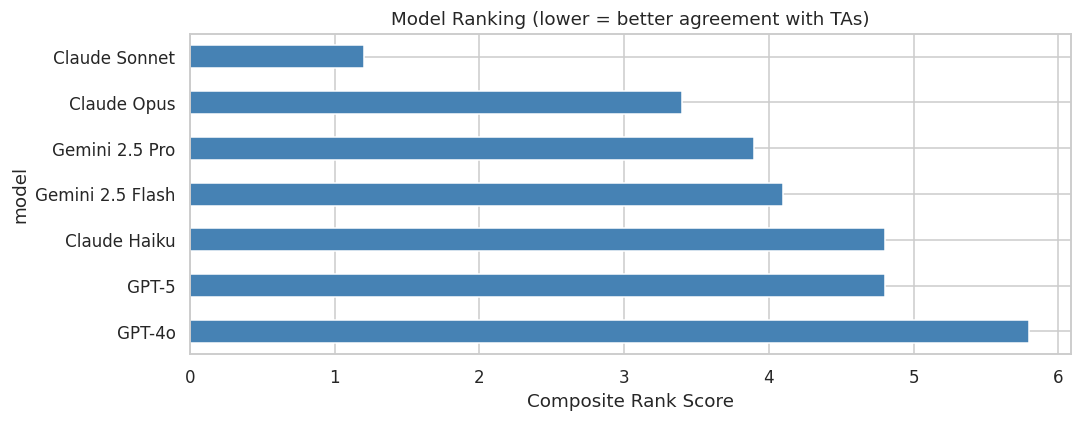

In [91]:
# 7.5 Ranking bar chart (composite rank)
fig, ax = plt.subplots(figsize=(10, 4))
ranking_plot = ranking.set_index("model")["composite_rank"].sort_values()
ranking_plot.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Model Ranking (lower = better agreement with TAs)")
ax.set_xlabel("Composite Rank Score")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("outputs/7_5_model_ranking.png", bbox_inches="tight")
plt.show()


## Phase 8 — Per-Question Deep Dive


In [92]:
# 8.1 Per-question Pearson correlation and MAE per model
q_agreement_rows = []
for (mlabel, q), grp in df_q.groupby(["model_label", "question"]):
    sub = grp[["llm_score", "ta_avg_q"]].dropna()
    if len(sub) < 3:
        continue
    pr, _ = pearsonr(sub["llm_score"], sub["ta_avg_q"])
    mae   = np.mean(np.abs(sub["llm_score"] - sub["ta_avg_q"]))
    bias  = np.mean(sub["llm_score"] - sub["ta_avg_q"])
    q_agreement_rows.append({
        "model": mlabel,
        "question": q,
        "pearson_r": round(pr, 3),
        "MAE": round(mae, 2),
        "bias": round(bias, 2),
        "n": len(sub),
    })

q_agree_df = pd.DataFrame(q_agreement_rows)

# Pivot: MAE by question x model
mae_pivot = q_agree_df.pivot_table(index="model", columns="question", values="MAE")
print("=== Per-Question MAE (rows=models, columns=questions) ===")
display(mae_pivot.round(2))


=== Per-Question MAE (rows=models, columns=questions) ===


question,Q1,Q2,Q3,Q4,Q5,Q6
model,,,,,,
Claude Haiku,3.86,3.30,2.67,1.47,4.61,7.76
Claude Opus,2.95,1.97,3.12,1.58,4.11,5.17
Claude Sonnet,2.78,2.51,2.87,1.31,4.53,5.90
GPT-4o,4.67,4.41,3.92,3.67,5.82,6.86
GPT-5,4.72,3.14,2.91,1.65,4.87,6.45
Gemini 2.5 Flash,3.69,2.61,2.93,1.98,5.25,5.89
Gemini 2.5 Pro,3.39,2.45,2.82,1.49,5.33,6.09


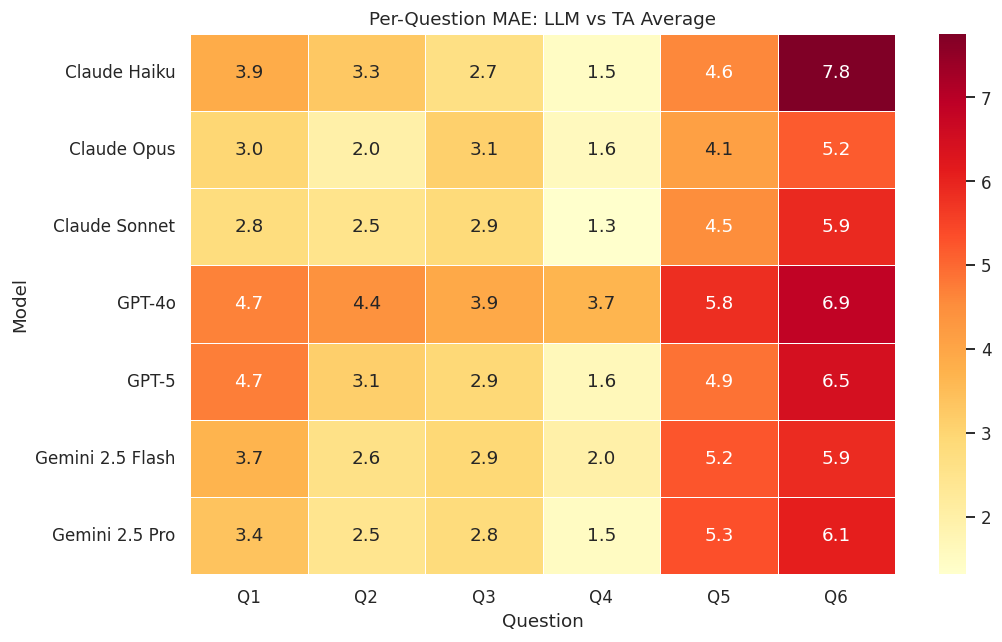

In [93]:
# 8.2 Heatmap: per-question MAE by model
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(mae_pivot, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax)
ax.set_title("Per-Question MAE: LLM vs TA Average")
ax.set_xlabel("Question")
ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig("outputs/8_2_per_question_mae_heatmap.png", bbox_inches="tight")
plt.show()


In [94]:
# 8.3 Identify questions with highest LLM-TA disagreement across all models
q_bias_summary = (
    q_agree_df.groupby("question")
    .agg(mean_MAE=("MAE", "mean"), mean_bias=("bias", "mean"),
         max_MAE=("MAE", "max"), std_MAE=("MAE", "std"))
    .sort_values("mean_MAE", ascending=False)
    .round(2)
)
print("=== Questions by Average LLM-TA Disagreement (all models) ===")
display(q_bias_summary)


=== Questions by Average LLM-TA Disagreement (all models) ===


,mean_MAE,mean_bias,max_MAE,std_MAE
question,,,,
Q6,6.30,-1.12,7.76,0.83
Q5,4.93,-0.39,5.82,0.58
Q1,3.72,-1.36,4.72,0.76
Q3,3.03,-2.14,3.92,0.41
Q2,2.91,-1.07,4.41,0.80
Q4,1.88,-0.19,3.67,0.82


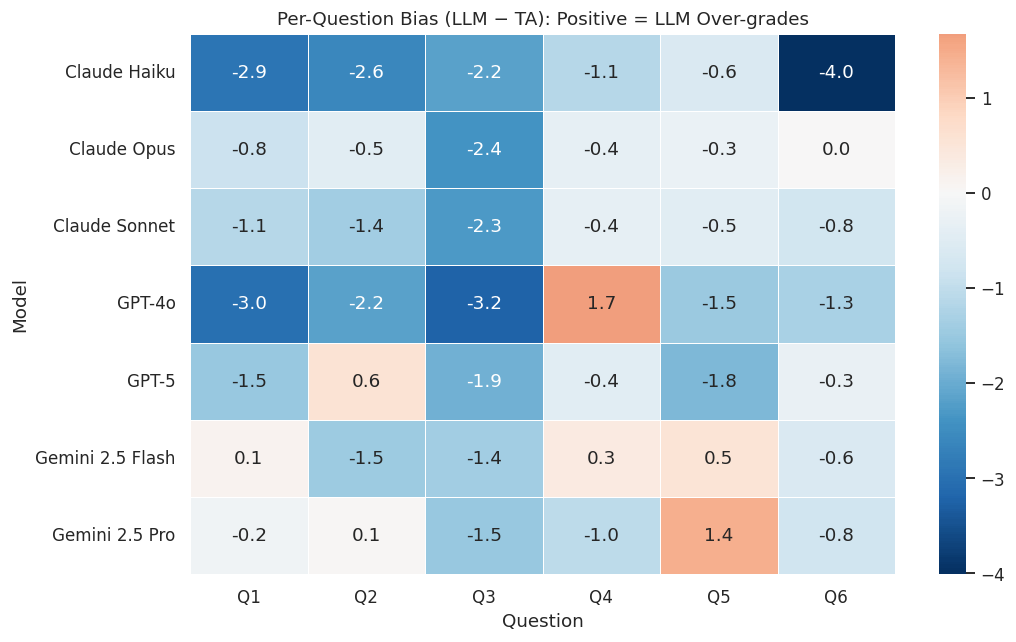

In [95]:
# 8.4 Bias heatmap per question x model
bias_pivot = q_agree_df.pivot_table(index="model", columns="question", values="bias")
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(bias_pivot, annot=True, fmt=".1f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Per-Question Bias (LLM − TA): Positive = LLM Over-grades")
ax.set_xlabel("Question")
ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig("outputs/8_4_per_question_bias_heatmap.png", bbox_inches="tight")
plt.show()


## Save Outputs


In [96]:
# Save cleaned dataset and key result tables
cleaned_cols = [
    "student_id", "model", "model_label", "run",
    "total_score", "total_points", "norm_score",
    "ta1_total_score", "ta2_total_score", "ta3_total_score",
    "ta_avg", "ta_std", "llm_bias", "llm_abs_error",
    "llm_grade", "ta_avg_grade", "is_outlier", "llm_call_time_taken",
]
df[cleaned_cols].to_csv("outputs/cleaned_sample.csv", index=False)
print("Saved: outputs/cleaned_sample.csv")

ranking.to_csv("outputs/model_ranking.csv", index=False)
print("Saved: outputs/model_ranking.csv")

q_agree_df.to_csv("outputs/per_question_agreement.csv", index=False)
print("Saved: outputs/per_question_agreement.csv")

print("\nAll outputs saved to outputs/")
print("Plots saved:")
import glob
for f in sorted(glob.glob("outputs/*.png")):
    print(" ", f)


Saved: outputs/cleaned_sample.csv
Saved: outputs/model_ranking.csv
Saved: outputs/per_question_agreement.csv

All outputs saved to outputs/
Plots saved:
  outputs/4_1_score_distributions.png
  outputs/4_2_llm_vs_ta_scatter.png
  outputs/4_3_bias_boxplot.png
  outputs/4_4_correlation_heatmap.png
  outputs/4_5_per_question_bar.png
  outputs/4_6_latency_boxplot.png
  outputs/5_4_bland_altman.png
  outputs/6_3_outlier_counts.png
  outputs/7_5_model_ranking.png
  outputs/8_2_per_question_mae_heatmap.png
  outputs/8_4_per_question_bias_heatmap.png
